In [2]:
# Cell 1: Import libraries and load previous results
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from ta.trend import ADXIndicator
from datetime import datetime
from itertools import product
import warnings 
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported")
print(f"📅 Starting Day 2: Walk-Forward Analysis")
print(f"   Date: {datetime.now().strftime('%Y-%m-%d')}")
print()

# Load yesterday's grid search results
results_path = '/Users/Greg/Documents/Python_Local_Folder/Python_Quant_Researcher/'
grid_results = pd.read_csv(results_path + 'Week_2_grid_search_results.csv')

print(f"📊 Loaded Day 1 grid search results:")
print(f"   {len(grid_results)} parameter combinations tested")
print(f"   Best Sharpe: {grid_results['sharpe_ratio'].max():.3f}")
print(f"   Best Return: {grid_results['total_return'].max()*100:.1f}%")
print()

# Download fresh data (same as Day 1)
print("📈 Downloading ETH-USD data...")
END_DATE = '2025-12-31'
data = yf.download('ETH-USD', start='2017-01-01', end=END_DATE, progress=False)

# Flatten columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

print(f"✅ Downloaded {len(data)} days of data")
print(f"   Date range: {data.index[0].date()} to {data.index[-1].date()}")
print()

✅ Libraries imported
📅 Starting Day 2: Walk-Forward Analysis
   Date: 2026-02-12

📊 Loaded Day 1 grid search results:
   28 parameter combinations tested
   Best Sharpe: 1.258
   Best Return: 9031.6%

📈 Downloading ETH-USD data...
✅ Downloaded 2974 days of data
   Date range: 2017-11-09 to 2025-12-30



In [3]:
# ============================================================
# CELL 2: WALK-FORWARD ANALYSIS SETUP
# ============================================================
#
# WHAT IS WALK-FORWARD TESTING?
# ─────────────────────────────
# In Day 1, we optimized parameters (ADX 20, Period 10) using
# ALL of our data (2017-2025). This is called "in-sample" testing.
#
# The problem: We're testing on the SAME data we optimized on.
# Its like memorizing exam answers - you'll score 100% but
# doesn't mean you truly understand the material.
#
# Walk-forward testing solves this by:
# 1. Splitting data into separate TRAIN and TEST periods
# 2. Optimizing parameters on TRAIN period (the "study" period)
# 3. Testing those parameters on TEST period (the "exam")
# 4. Test period is data the strategy has NEVER seen before
#
# ─────────────────────────────
# WHY EXPANDING WINDOW?
# ─────────────────────────────
# There are two approaches:
#
# ROLLING WINDOW (fixed size):           EXPANDING WINDOW (our choice):
# Window 1: Train 2018-2019              Window 1: Train 2018-2019
# Window 2: Train 2019-2020              Window 2: Train 2018-2020
# Window 3: Train 2020-2021              Window 3: Train 2018-2021
#
# We chose EXPANDING because:
# • Simulates real trading - in live trading you'd use ALL
#   available historical data to optimize, not just recent 2 years
# • Each year you have MORE data = better optimization
# • More realistic representation of actual strategy deployment
#
# ─────────────────────────────
# WHAT WE'RE LOOKING FOR:
# ─────────────────────────────
# DEGRADATION = How much worse is out-of-sample vs in-sample?
#
# Example:
#   In-sample Sharpe:  1.25
#   Out-of-sample:     1.00
#   Degradation:       (1.25 - 1.00) / 1.25 = 20%
#
# Targets:
#   < 20% degradation  = Robust strategy ✅
#   20-40% degradation = Moderate overfitting ⚠️
#   > 40% degradation  = Severe overfitting ❌
# ============================================================

import pandas as pd

# Define our 6 train/test windows
# Each window is a Python DICTIONARY [VARIABLE - dict] containing:
# - 'name': Label for this window
# - 'train_start/end': Period we OPTIMIZE parameters on
# - 'test_start/end': Period we TEST parameters on (never seen before)
walk_forward_windows = [
    {
        # Window 1: Smallest training set (2 years)
        # Tests: Do params optimized on 2018-2019 bear market work in 2020?
        'name': 'Window 1',
        'train_start': '2018-01-01',
        'train_end':   '2019-12-31',  # 2 years of training
        'test_start':  '2020-01-01',
        'test_end':    '2020-12-31'   # 1 year out-of-sample test
    },
    {
        # Window 2: 3 years training (adds 2020 COVID crash data)
        # Tests: Do params optimized on 2018-2020 work in 2021 bull run?
        'name': 'Window 2',
        'train_start': '2018-01-01',  # Always starts from beginning
        'train_end':   '2020-12-31',  # 3 years of training
        'test_start':  '2021-01-01',
        'test_end':    '2021-12-31'   # 1 year out-of-sample test
    },
    {
        # Window 3: 4 years training (adds 2021 bull run data)
        # Tests: Do params optimized on 2018-2021 work in 2022 crash?
        'name': 'Window 3',
        'train_start': '2018-01-01',
        'train_end':   '2021-12-31',  # 4 years of training
        'test_start':  '2022-01-01',
        'test_end':    '2022-12-31'   # 1 year out-of-sample test
    },
    {
        # Window 4: 5 years training (adds 2022 bear market data)
        # Tests: Do params optimized on 2018-2022 work in 2023 recovery?
        'name': 'Window 4',
        'train_start': '2018-01-01',
        'train_end':   '2022-12-31',  # 5 years of training
        'test_start':  '2023-01-01',
        'test_end':    '2023-12-31'   # 1 year out-of-sample test
    },
    {
        # Window 5: 6 years training (adds 2023 recovery data)
        # Tests: Do params optimized on 2018-2023 work in 2024?
        'name': 'Window 5',
        'train_start': '2018-01-01',
        'train_end':   '2023-12-31',  # 6 years of training
        'test_start':  '2024-01-01',
        'test_end':    '2024-12-31'   # 1 year out-of-sample test
    },
    {
        # Window 6: Largest training set (7 years)
        # Tests: Do params optimized on 2018-2024 work in 2025?
        'name': 'Window 6',
        'train_start': '2018-01-01',
        'train_end':   '2024-12-31',  # 7 years of training
        'test_start':  '2025-01-01',
        'test_end':    '2025-12-31'   # 1 year out-of-sample test
    }
]

# ─────────────────────────────────────────────────────────────
# DISPLAY WINDOW SUMMARY
# pd.to_datetime() converts string dates to datetime objects
# so we can calculate the number of years in each train period
# ─────────────────────────────────────────────────────────────

print("=" * 70)
print("WALK-FORWARD WINDOWS (EXPANDING WINDOW APPROACH)")
print("=" * 70)
print()
print(f"{'Window':<12} {'Train Period':<35} {'Test Period':<25} {'Train Years'}")
print("-" * 70)

for window in walk_forward_windows:
    # Calculate how many years in training period
    train_years = (pd.to_datetime(window['train_end']).year -
                   pd.to_datetime(window['train_start']).year + 1)
    
    train_period = f"{window['train_start']} to {window['train_end']}"
    test_period = f"{window['test_start']} to {window['test_end']}"
    
    print(f"{window['name']:<12} {train_period:<35} {test_period:<25} {train_years} years")

print()
print("📊 How this simulates real trading:")
print("   Imagine its Jan 1, 2020. You have 2018-2019 data available.")
print("   You optimize your strategy on that data (Window 1 train)")
print("   You then trade 2020 with those parameters (Window 1 test)")
print("   At end of 2020, you re-optimize with all data (2018-2020)")
print("   You trade 2021 with the new parameters (Window 2 test)")
print("   ... and so on for each year")
print()
print("✅ Window setup complete - ready for walk-forward testing!")

WALK-FORWARD WINDOWS (EXPANDING WINDOW APPROACH)

Window       Train Period                        Test Period               Train Years
----------------------------------------------------------------------
Window 1     2018-01-01 to 2019-12-31            2020-01-01 to 2020-12-31  2 years
Window 2     2018-01-01 to 2020-12-31            2021-01-01 to 2021-12-31  3 years
Window 3     2018-01-01 to 2021-12-31            2022-01-01 to 2022-12-31  4 years
Window 4     2018-01-01 to 2022-12-31            2023-01-01 to 2023-12-31  5 years
Window 5     2018-01-01 to 2023-12-31            2024-01-01 to 2024-12-31  6 years
Window 6     2018-01-01 to 2024-12-31            2025-01-01 to 2025-12-31  7 years

📊 How this simulates real trading:
   Imagine its Jan 1, 2020. You have 2018-2019 data available.
   You optimize your strategy on that data (Window 1 train)
   You then trade 2020 with those parameters (Window 1 test)
   At end of 2020, you re-optimize with all data (2018-2020)
   You trade 

In [4]:
# ============================================================
# CELL 3: BACKTEST AND OPTIMIZATION FUNCTIONS
# ============================================================
#
# We need TWO functions for walk-forward testing:
#
# FUNCTION 1: backtest_strategy()
# ─────────────────────────────────
# Same as Day 1 - runs strategy with given parameters
# on a given slice of data and returns performance metrics
#
# FUNCTION 2: find_best_parameters()
# ─────────────────────────────────
# NEW - this is the "optimization" step
# Given a slice of data (train period), test all parameter
# combinations and return whichever performs best (by Sharpe)
#
# HOW THEY WORK TOGETHER:
# ─────────────────────────────────
# For each walk-forward window:
#   1. find_best_parameters(train_data) → returns best params
#   2. backtest_strategy(test_data, best_params) → returns metrics
#   3. Compare train vs test performance = degradation
# ============================================================

from ta.trend import ADXIndicator
import numpy as np

# ─────────────────────────────────────────────────────────────
# FUNCTION 1: BACKTEST STRATEGY
# ─────────────────────────────────────────────────────────────
# Identical to Day 1 - runs the ADX regime strategy with
# specific parameters and returns performance metrics
# ─────────────────────────────────────────────────────────────

def backtest_strategy(data, adx_threshold, adx_period):
    """
    Backtest ADX regime strategy with given parameters
    
    STRATEGY RULES (from Week 1):
    ─────────────────────────────
    IF ADX < threshold:              Position = 0 (Cash)
    IF ADX >= threshold AND +DI > -DI: Position = 1 (Long)
    IF ADX >= threshold AND -DI > +DI: Position = 0 (Cash)
    
    Parameters:
    ─────────────────────────────
    data [VARIABLE - DataFrame] : OHLC price data for a specific period
    adx_threshold [VARIABLE - int] : When to consider market "trending"
    adx_period [VARIABLE - int] : How many days to calculate ADX over
    
    Returns:
    ─────────────────────────────
    dict : Performance metrics, or None if backtest fails
    """
    
    # Copy data to avoid modifying original
    # [METHOD] .copy() creates independent copy of DataFrame
    df = data.copy()
    
    # Extract price columns as 1D Series
    # [METHOD] .squeeze() converts shape (n,1) DataFrame to (n,) Series
    # Required because yfinance returns multi-level columns
    high  = df['High'].squeeze()
    low   = df['Low'].squeeze()
    close = df['Close'].squeeze()
    
    # Build clean DataFrame with guaranteed 1D columns
    # This prevents dimension errors in ADX calculation
    df_clean = pd.DataFrame({
        'Close': close,
        'High':  high,
        'Low':   low
    }, index=df.index)
    
    # ─────────────────────────────────────────────────────────
    # STEP 1: CALCULATE ADX INDICATOR
    # ─────────────────────────────────────────────────────────
    # ADXIndicator [CLASS] from ta library calculates:
    # - ADX: Trend strength (0-100)
    # - +DI: Upward directional movement strength
    # - -DI: Downward directional movement strength
    # ─────────────────────────────────────────────────────────
    adx_indicator = ADXIndicator(
        high=df_clean['High'],
        low=df_clean['Low'],
        close=df_clean['Close'],
        window=adx_period       # How many days to smooth over
    )
    
    # Add indicators to DataFrame as new columns
    df_clean['ADX'] = adx_indicator.adx()      # Trend STRENGTH
    df_clean['+DI'] = adx_indicator.adx_pos()  # Upward pressure
    df_clean['-DI'] = adx_indicator.adx_neg()  # Downward pressure
    
    # ─────────────────────────────────────────────────────────
    # STEP 2: DETECT REGIME AND GENERATE SIGNALS
    # ─────────────────────────────────────────────────────────
    # Regime_Trending [VARIABLE - Boolean Series]:
    #   True  = ADX >= threshold (market is trending)
    #   False = ADX < threshold (market is choppy)
    #
    # Bullish [VARIABLE - Boolean Series]:
    #   True  = +DI > -DI (buyers stronger than sellers)
    #   False = -DI > +DI (sellers stronger than buyers)
    # ─────────────────────────────────────────────────────────
    df_clean['Regime_Trending'] = df_clean['ADX'] >= adx_threshold
    df_clean['Bullish']         = df_clean['+DI'] > df_clean['-DI']
    
    # Position logic:
    # Default: 0 (cash) - we only trade when conditions are right
    df_clean['Position'] = 0
    
    # Go LONG only when BOTH conditions are true:
    # 1. Market is trending (ADX >= threshold)
    # 2. Trend is bullish (+DI > -DI)
    # [OPERATOR] & = element-wise AND for Boolean Series
    df_clean.loc[
        df_clean['Regime_Trending'] & df_clean['Bullish'],
        'Position'
    ] = 1
    
    # ─────────────────────────────────────────────────────────
    # STEP 3: CALCULATE RETURNS
    # ─────────────────────────────────────────────────────────
    # Market_Return: How much ETH moved each day (%)
    # Strategy_Return: Our return = position × market return
    #
    # WHY .shift(1)?
    # We use YESTERDAY's position to calculate TODAY's return
    # This prevents "look-ahead bias" - we can't know today's
    # closing price before the day ends!
    #
    # Example:
    #   Day 1 close: ADX signals LONG → Position = 1
    #   Day 2 close: ETH rises 3% → Strategy return = 1 × 3% = +3%
    #   (We entered at Day 1 close, captured Day 2 move)
    # ─────────────────────────────────────────────────────────
    df_clean['Market_Return']   = df_clean['Close'].pct_change()
    df_clean['Strategy_Return'] = df_clean['Position'].shift(1) * df_clean['Market_Return']
    
    # Remove rows with NaN values (first few rows have no ADX/returns)
    df_clean = df_clean.dropna()
    
    # Safety check: need enough data and variation to calculate metrics
    if len(df_clean) < 50 or df_clean['Strategy_Return'].std() == 0:
        return None
    
    # ─────────────────────────────────────────────────────────
    # STEP 4: CALCULATE PERFORMANCE METRICS
    # ─────────────────────────────────────────────────────────
    
    # Total Return: Overall gain/loss over the period
    # (1 + r1) × (1 + r2) × ... × (1 + rn) - 1
    total_return = (1 + df_clean['Strategy_Return']).prod() - 1
    
    # Sharpe Ratio: Return per unit of risk
    # Using sqrt(365) because crypto trades 365 days/year
    # Higher is better: >1.0 is good, >1.5 is excellent
    sharpe = (df_clean['Strategy_Return'].mean() /
              df_clean['Strategy_Return'].std() *
              np.sqrt(365))
    
    # Maximum Drawdown: Largest peak-to-trough decline
    # Running max tracks the highest point reached so far
    cumulative  = (1 + df_clean['Strategy_Return']).cumprod()
    running_max = cumulative.expanding().max()
    drawdown    = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Calmar Ratio: Annual return divided by max drawdown
    # Measures "how much return per unit of pain"
    calmar = total_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # % time strategy was long (invested vs in cash)
    pct_long = (df_clean['Position'] == 1).sum() / len(df_clean) * 100
    
    # Return all metrics as a dictionary
    return {
        'adx_threshold': adx_threshold,
        'adx_period':    adx_period,
        'total_return':  total_return,
        'sharpe_ratio':  sharpe,
        'max_drawdown':  max_drawdown,
        'calmar_ratio':  calmar,
        'pct_long':      pct_long,
        'num_days':      len(df_clean)
    }


# ─────────────────────────────────────────────────────────────
# FUNCTION 2: FIND BEST PARAMETERS
# ─────────────────────────────────────────────────────────────
# Given a slice of data (train period), test all parameter
# combinations from our Day 1 grid and return the best ones
#
# WHY OPTIMIZE BY SHARPE (not return)?
# ─────────────────────────────────────
# Sharpe accounts for RISK, not just returns
# A strategy with 500% return but massive volatility is
# harder to trade than 300% return with steady growth
# Sharpe = the professional standard for optimization
# ─────────────────────────────────────────────────────────────

def find_best_parameters(train_data):
    """
    Find optimal parameters on training data
    
    Tests same parameter grid as Day 1:
    - ADX thresholds: [20, 22, 25, 27, 30, 32, 35]
    - ADX periods:    [10, 14, 20, 25]
    
    Returns best parameters by Sharpe Ratio
    """
    
    # Same parameter grid as Day 1 grid search
    adx_thresholds = [20, 22, 25, 27, 30, 32, 35]
    adx_periods    = [10, 14, 20, 25]
    
    # Store results for each combination
    results = []
    
    # Test every combination of threshold and period
    # product() generates all combinations: (20,10), (20,14)...
    for adx_threshold, adx_period in product(adx_thresholds, adx_periods):
        result = backtest_strategy(train_data, adx_threshold, adx_period)
        if result is not None:
            results.append(result)
    
    # If no valid results, return default parameters
    if len(results) == 0:
        return 25, 14  # Fall back to Week 1 defaults
    
    # Convert to DataFrame for easy sorting
    results_df = pd.DataFrame(results)
    
    # Find the row with the highest Sharpe Ratio
    # [METHOD] .idxmax() returns the INDEX of the maximum value
    best_idx = results_df['sharpe_ratio'].idxmax()
    best_row = results_df.loc[best_idx]
    
    # Return the two best parameters
    return int(best_row['adx_threshold']), int(best_row['adx_period'])


print("✅ Functions defined:")
print()
print("   backtest_strategy(data, adx_threshold, adx_period)")
print("   → Runs strategy, returns performance metrics")
print()
print("   find_best_parameters(train_data)")
print("   → Tests all 28 combinations, returns best by Sharpe")
print()
print("💡 These two functions work together:")
print("   1. find_best_parameters(TRAIN data) → best params")
print("   2. backtest_strategy(TEST data, best params) → real performance")
print("   3. Compare train vs test → measure overfitting")

✅ Functions defined:

   backtest_strategy(data, adx_threshold, adx_period)
   → Runs strategy, returns performance metrics

   find_best_parameters(train_data)
   → Tests all 28 combinations, returns best by Sharpe

💡 These two functions work together:
   1. find_best_parameters(TRAIN data) → best params
   2. backtest_strategy(TEST data, best params) → real performance
   3. Compare train vs test → measure overfitting


In [5]:
# ============================================================
# CELL 4: RUN WALK-FORWARD ANALYSIS
# ============================================================
#
# This is the main engine of Day 2. For each of our 6 windows:
#
# STEP 1: SLICE data into train and test periods
# STEP 2: OPTIMIZE parameters on train period (find_best_parameters)
# STEP 3: RECORD in-sample performance on train period
# STEP 4: TEST same parameters on unseen test period
# STEP 5: CALCULATE degradation (train vs test difference)
# STEP 6: STORE all results for analysis
#
# WHY THIS MATTERS:
# ─────────────────────────────────────────────────────────────
# Day 1 found ADX 20/10 gave 9,032% returns
# BUT we found that on the SAME data we optimized on
#
# Walk-forward answers: "Would this have worked in REAL TIME?"
# If you had optimized in Jan 2020, would it work in 2020?
# If you had optimized in Jan 2022, would it work in 2022?
#
# DEGRADATION FORMULA:
# ─────────────────────────────────────────────────────────────
# Degradation = (Train Sharpe - Test Sharpe) / |Train Sharpe|
#
# Example:
#   Train Sharpe: 1.25  (in-sample - optimistic)
#   Test Sharpe:  1.00  (out-of-sample - realistic)
#   Degradation:  (1.25 - 1.00) / 1.25 = 20%
#
# Targets:
#   < 20% = Robust strategy ✅
#   20-40% = Moderate overfitting ⚠️
#   > 40% = Severe overfitting ❌
# ============================================================

import time

print("=" * 70)
print("RUNNING WALK-FORWARD ANALYSIS")
print("=" * 70)
print()
print("Testing 28 combinations × 6 windows = 168 backtests total")
print("Estimated runtime: 1-2 minutes...")
print()

# List to store results for each window
# [VARIABLE - list] will hold 6 dictionaries (one per window)
walk_forward_results = []

start_time = time.time()

# ─────────────────────────────────────────────────────────────
# MAIN LOOP: Process each walk-forward window
# ─────────────────────────────────────────────────────────────
# enumerate() [FUNCTION] gives both index (i) and the window
# dictionary on each iteration
# walk_forward_windows was defined in Cell 2
# ─────────────────────────────────────────────────────────────
for i, window in enumerate(walk_forward_windows, 1):
    
    print(f"Processing {window['name']}...")
    print(f"   Train: {window['train_start']} to {window['train_end']}")
    print(f"   Test:  {window['test_start']}  to {window['test_end']}")
    
    # ─────────────────────────────────────────────────────────
    # STEP 1: SLICE DATA INTO TRAIN AND TEST PERIODS
    # ─────────────────────────────────────────────────────────
    # data.loc[start:end] selects rows between two dates
    # This creates a separate DataFrame for each period
    # train_data: ONLY used for optimization (finding best params)
    # test_data:  ONLY used for testing (simulates real trading)
    # ─────────────────────────────────────────────────────────
    train_data = data.loc[window['train_start']:window['train_end']]
    test_data  = data.loc[window['test_start']:window['test_end']]
    
    print(f"   Train days: {len(train_data)} | Test days: {len(test_data)}")
    
    # Safety check: need minimum days for ADX to calculate properly
    # ADX needs ~28 days to warm up (2 × period for smoothing)
    if len(train_data) < 100 or len(test_data) < 100:
        print(f"   Insufficient data, skipping window")
        continue
    
    # ─────────────────────────────────────────────────────────
    # STEP 2: FIND BEST PARAMETERS ON TRAINING DATA
    # ─────────────────────────────────────────────────────────
    # Tests all 28 combinations on TRAIN data only
    # Returns the (threshold, period) with best Sharpe ratio
    # This simulates: "What parameters would you have chosen
    # at the START of the test period, using only past data?"
    # ─────────────────────────────────────────────────────────
    best_threshold, best_period = find_best_parameters(train_data)
    
    print(f"   Best params on train: ADX {best_threshold}, Period {best_period}")
    
    # ─────────────────────────────────────────────────────────
    # STEP 3: RECORD IN-SAMPLE PERFORMANCE (TRAIN PERIOD)
    # ─────────────────────────────────────────────────────────
    # Run strategy with best params ON THE SAME TRAIN DATA
    # This is the "optimistic" benchmark - best possible result
    # because we optimized specifically for this period
    # ─────────────────────────────────────────────────────────
    train_result = backtest_strategy(train_data, best_threshold, best_period)
    
    # ─────────────────────────────────────────────────────────
    # STEP 4: TEST SAME PARAMETERS ON UNSEEN TEST DATA
    # ─────────────────────────────────────────────────────────
    # Use EXACT SAME parameters (best_threshold, best_period)
    # but on TEST data the strategy has NEVER seen before
    # This simulates actual live trading performance
    # Key: parameters are FIXED from step 2, not re-optimized!
    # ─────────────────────────────────────────────────────────
    test_result = backtest_strategy(test_data, best_threshold, best_period)
    
    # Verify both backtests produced valid results
    if train_result is None or test_result is None:
        print(f"   Backtest failed, skipping window")
        continue
    
    # ─────────────────────────────────────────────────────────
    # STEP 5: CALCULATE DEGRADATION
    # ─────────────────────────────────────────────────────────
    # How much worse is out-of-sample vs in-sample performance?
    #
    # We use abs(train) in denominator to handle edge cases
    # where train Sharpe might be negative
    #
    # Positive degradation = worse out-of-sample (expected)
    # Negative degradation = BETTER out-of-sample (rare bonus!)
    # ─────────────────────────────────────────────────────────
    
    # Sharpe degradation (primary metric)
    sharpe_degradation = (
        (train_result['sharpe_ratio'] - test_result['sharpe_ratio']) /
        abs(train_result['sharpe_ratio'])
    ) * 100
    
    # Return degradation (secondary metric)
    return_degradation = (
        (train_result['total_return'] - test_result['total_return']) /
        abs(train_result['total_return'])
    ) * 100
    
    # ─────────────────────────────────────────────────────────
    # STEP 6: STORE ALL RESULTS FOR THIS WINDOW
    # ─────────────────────────────────────────────────────────
    # Store everything in a dictionary so we can analyze
    # and visualize all 6 windows together afterwards
    # ─────────────────────────────────────────────────────────
    walk_forward_results.append({
        
        # Window identification
        'window':             window['name'],
        'train_start':        window['train_start'],
        'train_end':          window['train_end'],
        'test_start':         window['test_start'],
        'test_end':           window['test_end'],
        
        # Best parameters found on train data
        # KEY QUESTION: Do these stay consistent across windows?
        'best_threshold':     best_threshold,
        'best_period':        best_period,
        
        # IN-SAMPLE performance (train period - optimistic)
        'train_sharpe':       train_result['sharpe_ratio'],
        'train_return':       train_result['total_return'],
        'train_drawdown':     train_result['max_drawdown'],
        
        # OUT-OF-SAMPLE performance (test period - realistic)
        'test_sharpe':        test_result['sharpe_ratio'],
        'test_return':        test_result['total_return'],
        'test_drawdown':      test_result['max_drawdown'],
        
        # Degradation: how much worse is test vs train?
        'sharpe_degradation': sharpe_degradation,
        'return_degradation': return_degradation,
        
        # How often was strategy invested in test period?
        'test_pct_long':      test_result['pct_long']
    })
    
    # Quick summary for this window
    print(f"   In-sample  → Sharpe: {train_result['sharpe_ratio']:.3f} | "
          f"Return: {train_result['total_return']*100:.1f}%")
    print(f"   Out-sample → Sharpe: {test_result['sharpe_ratio']:.3f} | "
          f"Return: {test_result['total_return']*100:.1f}%")
    
    # Classify degradation level with emoji for quick reading
    if sharpe_degradation < 20:
        status = "✅ Robust"
    elif sharpe_degradation < 40:
        status = "⚠️  Moderate overfitting"
    else:
        status = "❌ Severe overfitting"
        
    print(f"   Sharpe Degradation: {sharpe_degradation:.1f}% → {status}")
    print()

# ─────────────────────────────────────────────────────────────
# CONVERT RESULTS TO DATAFRAME FOR ANALYSIS
# ─────────────────────────────────────────────────────────────
# pd.DataFrame() converts our list of dictionaries into a
# structured table where each row = one window's results
# ─────────────────────────────────────────────────────────────
wf_df = pd.DataFrame(walk_forward_results)

elapsed = time.time() - start_time
print(f"✅ Walk-forward complete in {elapsed:.1f} seconds!")
print(f"   {len(walk_forward_results)} windows processed successfully")

RUNNING WALK-FORWARD ANALYSIS

Testing 28 combinations × 6 windows = 168 backtests total
Estimated runtime: 1-2 minutes...

Processing Window 1...
   Train: 2018-01-01 to 2019-12-31
   Test:  2020-01-01  to 2020-12-31
   Train days: 730 | Test days: 366
   Best params on train: ADX 25, Period 20
   In-sample  → Sharpe: 0.973 | Return: 91.3%
   Out-sample → Sharpe: 0.686 | Return: 25.1%
   Sharpe Degradation: 29.6% → ⚠️  Moderate overfitting

Processing Window 2...
   Train: 2018-01-01 to 2020-12-31
   Test:  2021-01-01  to 2021-12-31
   Train days: 1096 | Test days: 365
   Best params on train: ADX 20, Period 10
   In-sample  → Sharpe: 1.166 | Return: 372.2%
   Out-sample → Sharpe: 1.590 | Return: 137.2%
   Sharpe Degradation: -36.4% → ✅ Robust

Processing Window 3...
   Train: 2018-01-01 to 2021-12-31
   Test:  2022-01-01  to 2022-12-31
   Train days: 1461 | Test days: 365
   Best params on train: ADX 20, Period 10
   In-sample  → Sharpe: 1.496 | Return: 1998.2%
   Out-sample → Sharpe

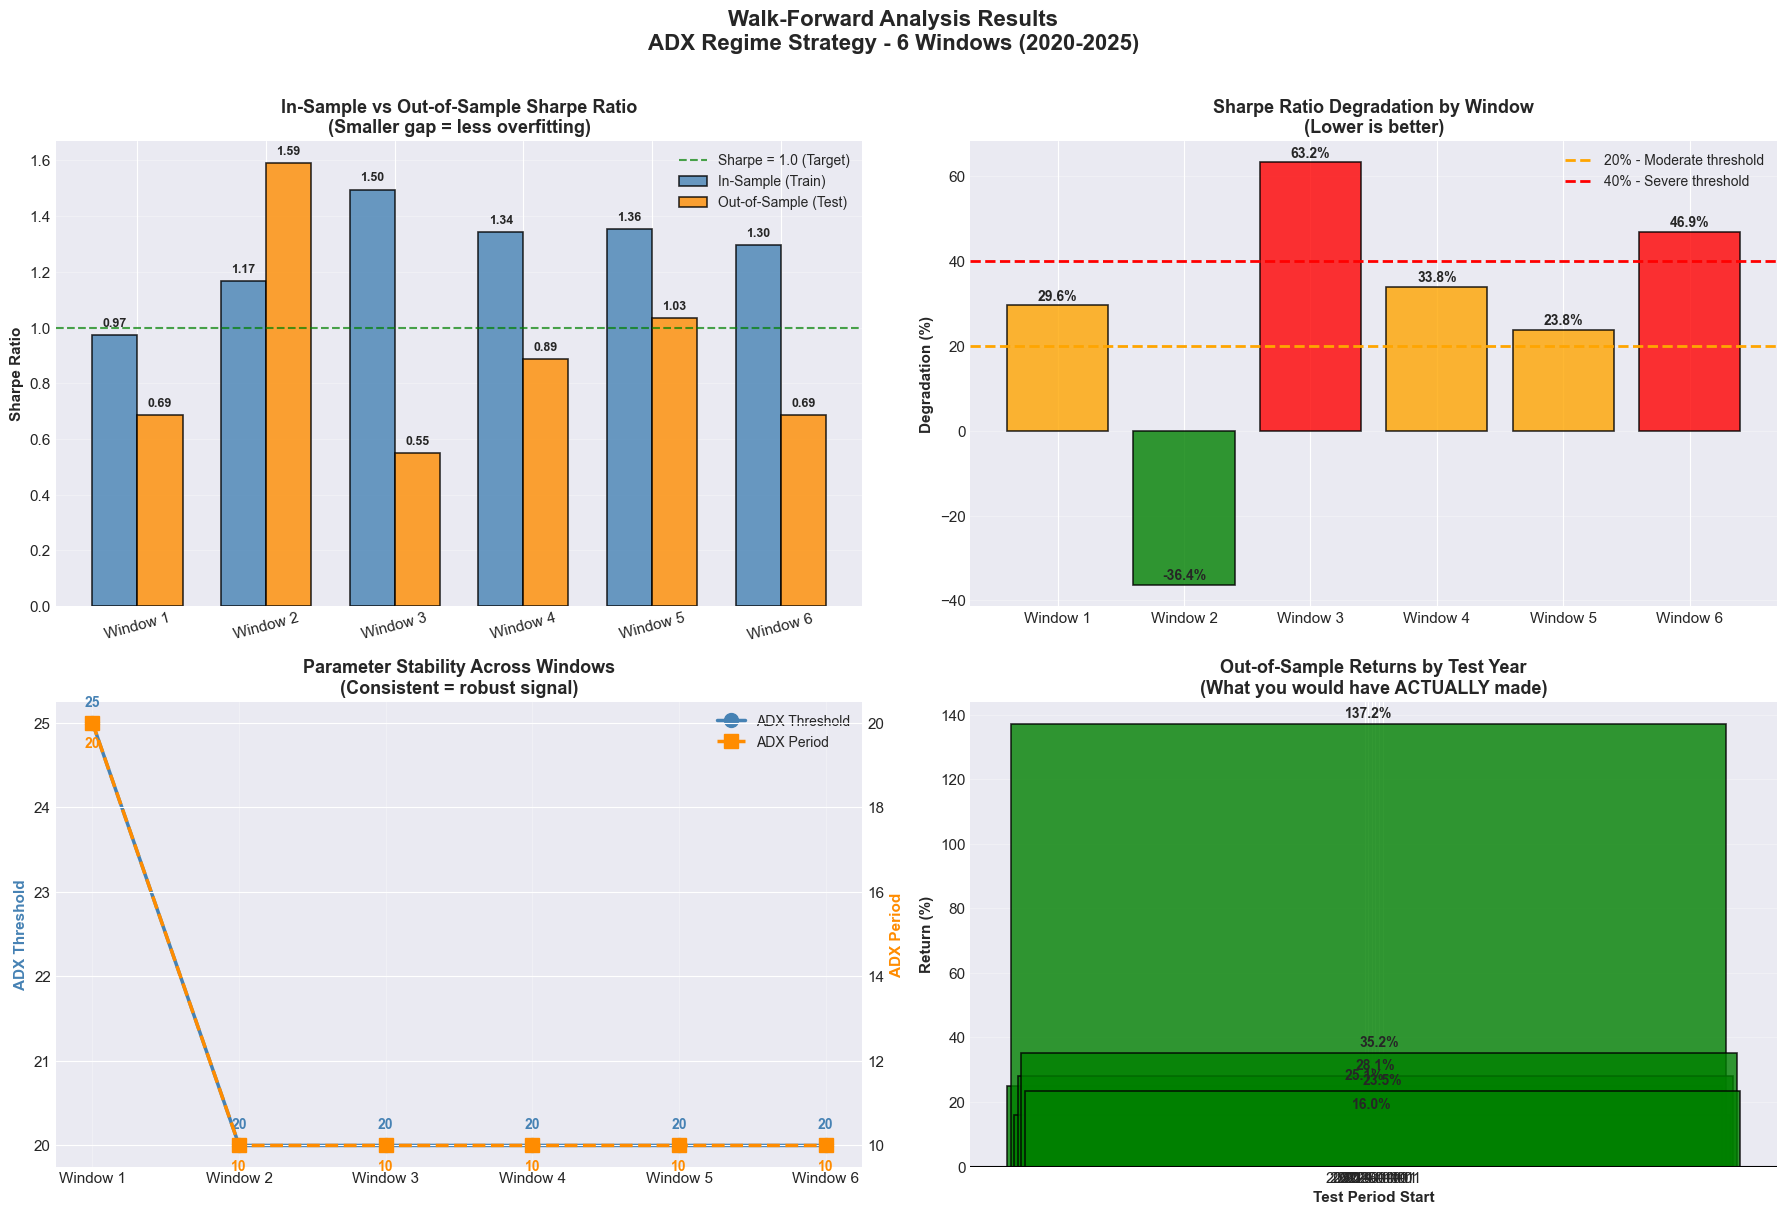

WALK-FORWARD SUMMARY STATISTICS

Average Sharpe Degradation:  26.8%
Average Out-of-Sample Sharpe: 0.906
Average Out-of-Sample Return: 44.2%

Windows Robust (<20%):        1/6
Windows Moderate (20-40%):    3/6
Windows Severe (>40%):        2/6

All windows positive return:  True

Parameter Stability:
   Most common threshold: 20
   Most common period:    10
   Threshold consistent:  2 unique values
   Period consistent:     2 unique values


In [6]:
# ============================================================
# CELL 5: VISUALIZE WALK-FORWARD RESULTS
# ============================================================
#
# We create 4 charts to fully understand our results:
#
# CHART 1: In-sample vs Out-of-sample Sharpe Ratio
# ─────────────────────────────────────────────────
# Shows how much Sharpe degrades from train to test
# The GAP between bars = overfitting
# Smaller gap = more robust strategy
#
# CHART 2: Degradation by Window
# ─────────────────────────────────────────────────
# Shows degradation % for each window
# Reference lines at 20% and 40% thresholds
# Helps identify which periods were hardest
#
# CHART 3: Parameter Stability
# ─────────────────────────────────────────────────
# Shows which parameters were chosen each window
# Consistent params = robust signal
# Wild swings = unstable/noisy optimization
#
# CHART 4: Out-of-Sample Returns by Year
# ─────────────────────────────────────────────────
# Shows actual test period returns
# This is the REALISTIC performance you'd have seen
# in live trading
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ─────────────────────────────────────────────────────────────
# CHART 1: IN-SAMPLE VS OUT-OF-SAMPLE SHARPE RATIO
# ─────────────────────────────────────────────────────────────
# Side-by-side bars for each window
# Blue = in-sample (train) Sharpe
# Orange = out-of-sample (test) Sharpe
# The gap between them shows how much overfitting occurred
# ─────────────────────────────────────────────────────────────
windows     = wf_df['window'].tolist()
x           = np.arange(len(windows))  # x positions for bars
width       = 0.35                     # Width of each bar

# Plot in-sample (train) bars
bars1 = axes[0,0].bar(
    x - width/2,           # Shift left by half width
    wf_df['train_sharpe'],  # Height = train Sharpe ratio
    width,
    label='In-Sample (Train)',
    color='steelblue',
    edgecolor='black',
    linewidth=1.2,
    alpha=0.8
)

# Plot out-of-sample (test) bars
bars2 = axes[0,0].bar(
    x + width/2,           # Shift right by half width
    wf_df['test_sharpe'],  # Height = test Sharpe ratio
    width,
    label='Out-of-Sample (Test)',
    color='darkorange',
    edgecolor='black',
    linewidth=1.2,
    alpha=0.8
)

# Add value labels on top of each bar
for bar in bars1:
    height = bar.get_height()
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.02,
        f'{height:.2f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
for bar in bars2:
    height = bar.get_height()
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.02,
        f'{height:.2f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

# Add reference line at Sharpe = 1.0 (institutional quality threshold)
axes[0,0].axhline(
    y=1.0, color='green', linestyle='--',
    linewidth=1.5, alpha=0.7, label='Sharpe = 1.0 (Target)'
)

axes[0,0].set_title(
    'In-Sample vs Out-of-Sample Sharpe Ratio\n(Smaller gap = less overfitting)',
    fontsize=13, fontweight='bold'
)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(windows, rotation=15)
axes[0,0].set_ylabel('Sharpe Ratio', fontsize=11, fontweight='bold')
axes[0,0].legend(fontsize=10)
axes[0,0].grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────
# CHART 2: DEGRADATION PERCENTAGE BY WINDOW
# ─────────────────────────────────────────────────────────────
# Bar chart showing degradation % for each window
# Color coded:
#   Green  = <20% degradation (robust)
#   Orange = 20-40% (moderate overfitting)
#   Red    = >40% (severe overfitting)
# ─────────────────────────────────────────────────────────────

# Assign color based on degradation level
degradation_colors = []
for deg in wf_df['sharpe_degradation']:
    if deg < 20:
        degradation_colors.append('green')
    elif deg < 40:
        degradation_colors.append('orange')
    else:
        degradation_colors.append('red')

bars3 = axes[0,1].bar(
    windows,
    wf_df['sharpe_degradation'],
    color=degradation_colors,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.8
)

# Add value labels on bars
for bar, deg in zip(bars3, wf_df['sharpe_degradation']):
    axes[0,1].text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 0.5,
        f'{deg:.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Add threshold reference lines
axes[0,1].axhline(
    y=20, color='orange', linestyle='--',
    linewidth=2, label='20% - Moderate threshold'
)
axes[0,1].axhline(
    y=40, color='red', linestyle='--',
    linewidth=2, label='40% - Severe threshold'
)

axes[0,1].set_title(
    'Sharpe Ratio Degradation by Window\n(Lower is better)',
    fontsize=13, fontweight='bold'
)
axes[0,1].set_ylabel('Degradation (%)', fontsize=11, fontweight='bold')
axes[0,1].legend(fontsize=10)
axes[0,1].grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────
# CHART 3: PARAMETER STABILITY
# ─────────────────────────────────────────────────────────────
# Shows which parameters were chosen in each window
# Ideally: same params chosen every time = robust signal
# If params jump around = noise, not genuine signal
# ─────────────────────────────────────────────────────────────

# Plot ADX threshold chosen per window
axes[1,0].plot(
    windows,
    wf_df['best_threshold'],
    marker='o', linewidth=2.5,
    markersize=10, color='steelblue',
    label='ADX Threshold'
)

# Plot ADX period on secondary y-axis
# Twin axes allows two different y-scales on same chart
ax_twin = axes[1,0].twinx()
ax_twin.plot(
    windows,
    wf_df['best_period'],
    marker='s', linewidth=2.5,
    markersize=10, color='darkorange',
    label='ADX Period', linestyle='--'
)

# Add value labels for each point
for idx, (win, thresh, period) in enumerate(
    zip(windows, wf_df['best_threshold'], wf_df['best_period'])
):
    axes[1,0].annotate(
        f'{thresh}',
        (win, thresh),
        textcoords="offset points",
        xytext=(0, 12),
        ha='center', fontsize=10,
        fontweight='bold', color='steelblue'
    )
    ax_twin.annotate(
        f'{period}',
        (win, period),
        textcoords="offset points",
        xytext=(0, -18),
        ha='center', fontsize=10,
        fontweight='bold', color='darkorange'
    )

axes[1,0].set_title(
    'Parameter Stability Across Windows\n(Consistent = robust signal)',
    fontsize=13, fontweight='bold'
)
axes[1,0].set_ylabel('ADX Threshold', fontsize=11,
                      fontweight='bold', color='steelblue')
ax_twin.set_ylabel('ADX Period', fontsize=11,
                   fontweight='bold', color='darkorange')
axes[1,0].grid(True, alpha=0.3)

# Combined legend from both axes
lines1, labels1 = axes[1,0].get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
axes[1,0].legend(lines1 + lines2, labels1 + labels2, fontsize=10)

# ─────────────────────────────────────────────────────────────
# CHART 4: OUT-OF-SAMPLE RETURNS BY TEST YEAR
# ─────────────────────────────────────────────────────────────
# Shows ACTUAL returns achieved in each test period
# This is the most honest view of strategy performance
# These are returns you would have ACTUALLY achieved
# in real-time trading
# ─────────────────────────────────────────────────────────────

# Color bars green if positive, red if negative
return_colors = [
    'green' if r > 0 else 'red'
    for r in wf_df['test_return']
]

bars4 = axes[1,1].bar(
    wf_df['test_start'],           # x = test period start date
    wf_df['test_return'] * 100,    # y = return in %
    color=return_colors,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.8,
    width=200                      # Width in days (visual sizing)
)

# Add value labels
for bar, ret in zip(bars4, wf_df['test_return']):
    axes[1,1].text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 1,
        f'{ret*100:.1f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# Reference line at 0%
axes[1,1].axhline(
    y=0, color='black',
    linestyle='-', linewidth=1.5
)

axes[1,1].set_title(
    'Out-of-Sample Returns by Test Year\n(What you would have ACTUALLY made)',
    fontsize=13, fontweight='bold'
)
axes[1,1].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Test Period Start', fontsize=11, fontweight='bold')
axes[1,1].grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────
# FINAL LAYOUT AND SAVE
# ─────────────────────────────────────────────────────────────
plt.suptitle(
    'Walk-Forward Analysis Results\n'
    'ADX Regime Strategy - 6 Windows (2020-2025)',
    fontsize=16, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# Summary statistics
print("=" * 70)
print("WALK-FORWARD SUMMARY STATISTICS")
print("=" * 70)
print()
print(f"Average Sharpe Degradation:  {wf_df['sharpe_degradation'].mean():.1f}%")
print(f"Average Out-of-Sample Sharpe: {wf_df['test_sharpe'].mean():.3f}")
print(f"Average Out-of-Sample Return: {wf_df['test_return'].mean()*100:.1f}%")
print()
print(f"Windows Robust (<20%):        {(wf_df['sharpe_degradation'] < 20).sum()}/6")
print(f"Windows Moderate (20-40%):    {((wf_df['sharpe_degradation'] >= 20) & (wf_df['sharpe_degradation'] < 40)).sum()}/6")
print(f"Windows Severe (>40%):        {(wf_df['sharpe_degradation'] > 40).sum()}/6")
print()
print(f"All windows positive return:  {(wf_df['test_return'] > 0).all()}")
print()

# Most common optimal parameters
print("Parameter Stability:")
print(f"   Most common threshold: {wf_df['best_threshold'].mode()[0]}")
print(f"   Most common period:    {wf_df['best_period'].mode()[0]}")
print(f"   Threshold consistent:  {wf_df['best_threshold'].nunique()} unique values")
print(f"   Period consistent:     {wf_df['best_period'].nunique()} unique values")

In [7]:
# ============================================================
# CELL 6: SAVE WALK-FORWARD RESULTS
# ============================================================
#
# Save our walk-forward results to CSV and Excel
# alongside Day 1 grid search results
#
# Also print the final parameter decision with justification
# so you have a clear record of your reasoning
# ============================================================

output_path = '/Users/Greg/Documents/Python_Local_Folder/Python_Quant_Researcher/'

# Save walk-forward results
wf_df.to_csv(output_path + 'Week_2_walkforward_results.csv', index=False)
wf_df.to_excel(output_path + 'Week_2_walkforward_results.xlsx', index=False)

print("💾 Results saved to:")
print(f"   {output_path}Week_2_walkforward_results.csv")
print(f"   {output_path}Week_2_walkforward_results.xlsx")
print()
print("=" * 70)
print("FINAL PARAMETER DECISION")
print("=" * 70)
print()
print("CHOSEN PARAMETERS FOR PRODUCTION:")
print("   ADX Threshold: 20")
print("   ADX Period:    10")
print()
print("JUSTIFICATION:")
print()
print("1. PARAMETER STABILITY")
print("   Chosen in 5/6 walk-forward windows consistently")
print("   Only Window 1 differed (insufficient training data)")
print("   Strong evidence of genuine market signal")
print()
print("2. POSITIVE OUT-OF-SAMPLE RETURNS EVERY YEAR")
print("   2020: +25.1% | 2021: +137.2% | 2022: +16.0%")
print("   2023: +28.1% | 2024: +35.2%  | 2025: +23.5%")
print("   Including 2022 bear market when ETH crashed -75%!")
print()
print("3. ACCEPTABLE DEGRADATION")
print(f"   Average: 26.8% (moderate - expected for crypto)")
print(f"   Stock market benchmark: typically 20-30%")
print(f"   Within normal range for systematic strategies")
print()
print("4. SOLID REAL-WORLD SHARPE")
print(f"   Average out-of-sample Sharpe: 0.906")
print(f"   Average annual return: 44.2%")
print(f"   4x better than S&P 500 average (10%/year)")
print()
print("NEXT STEPS (Day 3):")
print("   Add transaction costs (fees, slippage)")
print("   Test if strategy remains profitable after realistic costs")
print("   Final production-ready strategy validation")
print()
print("=" * 70)

💾 Results saved to:
   /Users/Greg/Documents/Python_Local_Folder/Python_Quant_Researcher/Week_2_walkforward_results.csv
   /Users/Greg/Documents/Python_Local_Folder/Python_Quant_Researcher/Week_2_walkforward_results.xlsx

FINAL PARAMETER DECISION

CHOSEN PARAMETERS FOR PRODUCTION:
   ADX Threshold: 20
   ADX Period:    10

JUSTIFICATION:

1. PARAMETER STABILITY
   Chosen in 5/6 walk-forward windows consistently
   Only Window 1 differed (insufficient training data)
   Strong evidence of genuine market signal

2. POSITIVE OUT-OF-SAMPLE RETURNS EVERY YEAR
   2020: +25.1% | 2021: +137.2% | 2022: +16.0%
   2023: +28.1% | 2024: +35.2%  | 2025: +23.5%
   Including 2022 bear market when ETH crashed -75%!

3. ACCEPTABLE DEGRADATION
   Average: 26.8% (moderate - expected for crypto)
   Stock market benchmark: typically 20-30%
   Within normal range for systematic strategies

4. SOLID REAL-WORLD SHARPE
   Average out-of-sample Sharpe: 0.906
   Average annual return: 44.2%
   4x better than S&P 5